In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.signal import find_peaks
from scipy import constants
from lmfit.models import LinearModel
from lmfit import Model

In [2]:
def plot_Hg(data_path):
    df = pd.read_csv('data/' + data_path)
    L = df['lambda [nm]']
    dL = df['dlambda [nm]']
    I = df['I [nA]']
    delta_I = df['dI [nA]']

    index, _ = find_peaks(I, height=5, distance=5) 
    L_peaks = L.iloc[index].values
    I_peaks = I.iloc[index].values

    fig, ax = plt.subplots(figsize= (6, 4), dpi=120)

    ax.scatter(L_peaks, I_peaks, color='red', s=30, marker='v', 
               label='Máximos Detectados', zorder=5)

    ax.plot(L,I, color='blue', linewidth=1, 
            label='Datos Experimentales', zorder=2)

    for i, txt in enumerate(L_peaks):
        ax.annotate(f'{txt:.1f}', (L_peaks[i], I_peaks[i]), 
                    textcoords="offset points", xytext=(0,10), ha='center', 
                    fontsize=7, color='red', fontweight='bold')

    ax.set_title(f'Espectro de lámpara de Mercurio ' + '($Hg$)', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Longitud de Onda $\lambda$ [nm]', fontsize=12)
    ax.set_ylabel('Intensidad $I$ [nA]', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right')

    ax.set_ylim(0, 32)

    plt.tight_layout()
    plt.savefig('plots/spectra_mercury.png', bbox_inches='tight')
    plt.show()

    peaks = [365.4, 404.7, 435.8, 546.1, 577]

    model = LinearModel()
    params = model.guess(peaks, x=L_peaks)
    result = model.fit(peaks, params, x=L_peaks, weights = 1)

    m_val = result.params['slope'].value
    m_err = result.params['slope'].stderr
    b_val = result.params['intercept'].value
    b_err = result.params['intercept'].stderr

    fig, (ax_res, ax_fit) = plt.subplots(2, 1, sharex=True, figsize=(7, 6), 
                                     gridspec_kw={'height_ratios': [1, 3]})
    ax_res.set_title(f'Ajuste lineal de la Longitud de Onda ' + '$\lambda$', 
                 fontsize=14, fontweight='bold', pad=15)

    ax_res.errorbar(L_peaks, result.residual, xerr=1, fmt='s', color='black', 
                ecolor='black', capsize=4, markersize=4, label='Residuos')
    ax_res.axhline(0, color='black', alpha=0.6, linewidth = 1) # Línea en el cero
    ax_res.set_ylabel('Residuos')
    ax_res.grid(True, linestyle='--', alpha=0.5)

    ax_fit.errorbar(L_peaks, peaks, xerr=2, fmt='s', color='black', 
                ecolor='black', capsize=4, markersize=4, label='Datos Experimentales')

    ax_fit.plot(L_peaks, result.best_fit, color='red', linewidth=1.5, label='Ajuste Lineal ($R^2 = 0.9999$)')

    ax_fit.set_xlabel('$\lambda_{teo}$ [nm]', fontsize=11)
    ax_fit.set_ylabel('$\lambda_{exp}$ [nm]', fontsize=11)
    ax_fit.grid(True, linestyle='--', alpha=0.6)
    ax_fit.legend(loc='upper left')

    texto_ecuacion = (
    f"$m = {m_val:.4f} \pm {m_err:.4f}$\n"
    f"$b = {b_val:.4f} \pm {b_err:.4f}$")

    propiedades_cuadro = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8)
    ax_fit.text(0.95, 0.05, texto_ecuacion, 
            transform=ax_fit.transAxes, # <-- Esto hace la magia
            fontsize=10, 
            bbox=propiedades_cuadro, 
            verticalalignment='bottom',
            horizontalalignment='right')

    plt.tight_layout()
    plt.savefig('plots/spectra_fit.png', bbox_inches='tight')
    plt.show()
    print(result.fit_report())
    return m_val, b_val

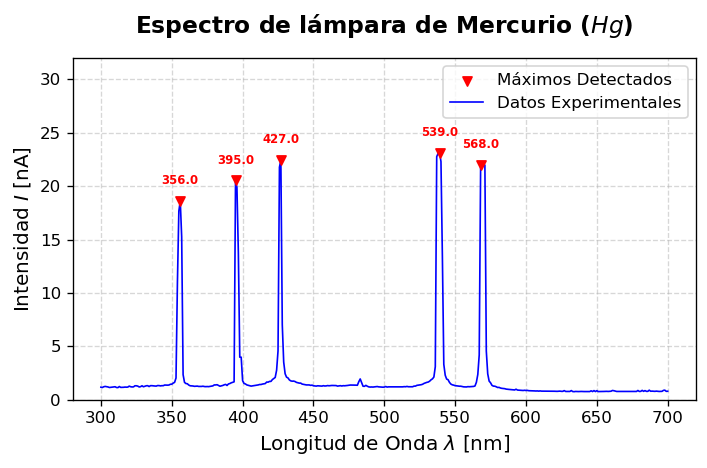

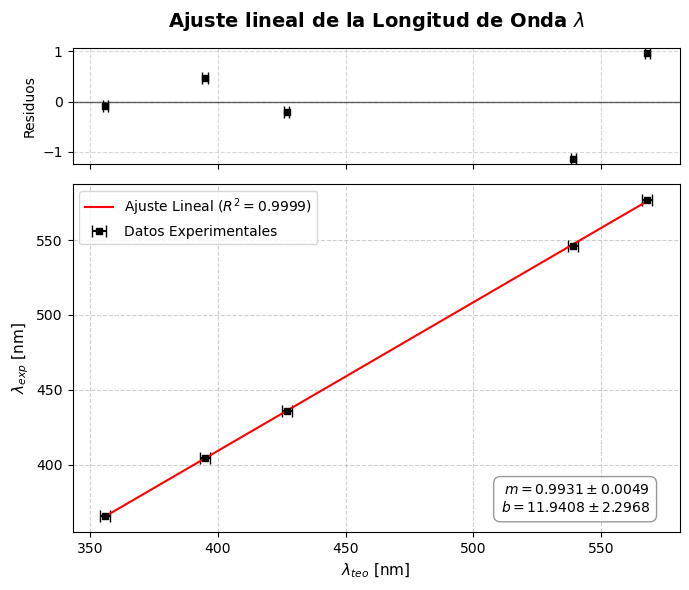

[[Model]]
    Model(linear)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 4
    # data points      = 5
    # variables        = 2
    chi-square         = 2.49455840
    reduced chi-square = 0.83151947
    Akaike info crit   = 0.52336903
    Bayesian info crit = -0.25775514
    R-squared          = 0.99992560
[[Variables]]
    slope:      0.99312739 +/- 0.00494607 (0.50%) (init = 0.9931274)
    intercept:  11.9407826 +/- 2.29684844 (19.24%) (init = 11.94078)
[[Correlations]] (unreported correlations are < 0.100)
    C(slope, intercept) = -0.9841


In [3]:
m, b  = plot_Hg('mercury_spectra_11_05_26.csv')

In [6]:
def plot_H2(data_path, m, b, count, dist =1.0, prom=1.0):
    df = pd.read_csv('data/' + data_path)
    l = df['lambda [nm]']
    d = df['dlambda [nm]']
    I = df['I [nA]']
    delta_I = df['dI [nA]']
    L = m*l + b
    dL = m*l

    index, _ = find_peaks(I, height=5, distance=dist, prominence =prom) 
    L_peaks = L.iloc[index].values
    I_peaks = I.iloc[index].values

    rango_H = [(405, 415),(429,439), (484, 488), (654, 658)] 
    rango_Na = [(587, 592)]   
    rango_Ne = [(455, 465), (573, 585)]

    H_x, H_y = [], []
    Na_x, Na_y = [], []
    Ne_x, Ne_y = [], []
    ruido_x, ruido_y = [], []

    for px, py in zip(L_peaks, I_peaks):
        es_hidrogeno = any(lim_inf <= px <= lim_sup for lim_inf, lim_sup in rango_H)
        es_sodio = any(lim_inf <= px <= lim_sup for lim_inf, lim_sup in rango_Na)
        es_neon = any(lim_inf <= px <= lim_sup for lim_inf, lim_sup in rango_Ne)
        if es_hidrogeno:
            H_x.append(px)
            H_y.append(py)
        elif es_sodio:
            Na_x.append(px)
            Na_y.append(py)
        elif es_neon:
            Ne_x.append(px)
            Ne_y.append(py)
        else:
            ruido_x.append(px)
            ruido_y.append(py)

    fig, ax = plt.subplots(figsize= (6, 4), dpi=120)

    if H_x:
        H_balmer = H_x
        ax.scatter(H_x, H_y, color='red', marker='v', s=30, zorder=3, label='Hidrógeno (H)')
    if Na_x:
        ax.scatter(Na_x, Na_y, color='green', marker='v', s=30, zorder=3, label='Sodio (Na)')
    if Ne_x:
        ax.scatter(Ne_x, Ne_y, color='purple', marker='v', s=30, zorder=3, label='Neón (Ne)')
    if ruido_x:
        ax.scatter(ruido_x, ruido_y, color='gray', marker='x', s=30, zorder=3, label='Ruido')

    def etiquetar_con_annotate(lista_x, lista_y, color_texto):
        for px, py in zip(lista_x, lista_y):
            ax.annotate(
                f"{px:.1f}",              
                xy=(px, py),                 
                xytext=(0, 10),              
                textcoords='offset points',  
                color=color_texto,
                fontsize=7,
                fontweight='bold',
                horizontalalignment='center',
                verticalalignment='bottom')

    etiquetar_con_annotate(H_x, H_y, color_texto='red')
    etiquetar_con_annotate(Na_x, Na_y, color_texto='green')
    etiquetar_con_annotate(Ne_x, Ne_y, color_texto='purple')
    #etiquetar_con_annotate(ruido_x, ruido_y, color_texto='gray')

    ax.plot(L,I, color='blue', linewidth=1, 
            label='Datos Experimentales', zorder=2)

    ax.set_title(f'Espectro de lámpara de Hidrógeno ' + '($H_2$)', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Longitud de Onda $\lambda$ [nm]', fontsize=12)
    ax.set_ylabel('Intensidad $I$ [nA]', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left')

    ax.set_ylim(5, 32)

    plt.tight_layout()
    plt.savefig('plots/spectra_hydrogen_'+ f'{count}'+ '.png', bbox_inches='tight')
    plt.show()
    return H_balmer

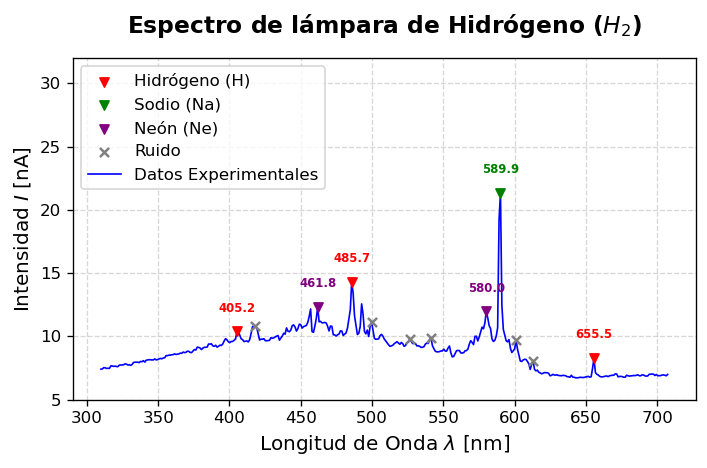

In [7]:
balmer_1 = plot_H2('hydrogen_spectra_1_11_05_26.csv', m = m, b = b, count = 1, dist = 10, prom =0.5)

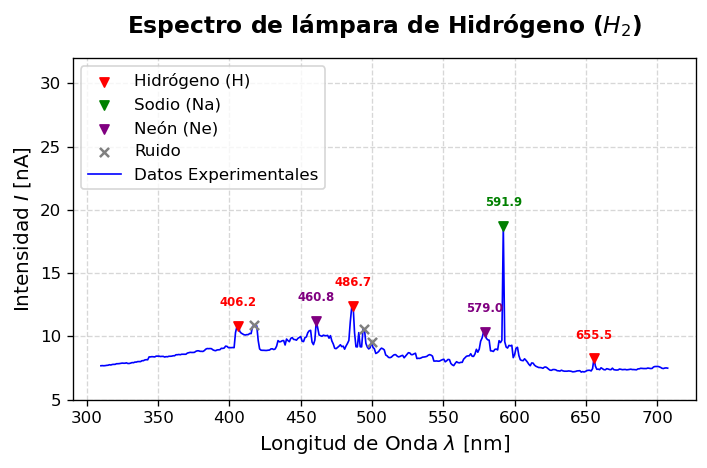

In [8]:
balmer_2 = plot_H2('hydrogen_spectra_2_11_05_26.csv', m = m, b = b, count = 2, dist = 5 , prom =0.5)

In [9]:
def calcular_rydberg(balmer):
    valores_R = []
    for punto in balmer:
        lam_metros = punto["lambda_exp"] * 1e-9
        ni = punto["n_i"]
        factor_cuantico = (1 / 4) - (1 / ni**2)
        R_individual = (1 / lam_metros) / factor_cuantico
        valores_R.append(R_individual)
        print(f"Para n = {ni} (λ = {punto['lambda_exp']:.2f} nm): R_H = {R_individual:.4e} m^-1")
    
    R_promedio = np.mean(valores_R)
    R_std = np.std(valores_R, ddof=1)
    exponente = 7
    factor = 10**exponente
    
    promedio_mantisa = R_promedio / factor
    std_mantisa = R_std / factor
    R_teorico = 1.0973731568e7
    print(f"R_H teórico = 1.0973 x 10^{exponente} m^-1")
    print(f"R_H experimental = ({promedio_mantisa:.4f} ± {std_mantisa:.4f}) x 10^{exponente} m^-1")
    
    R_teorico = 1.0973731568e7
    error_relativo = abs(R_promedio - R_teorico) / R_teorico * 100
    print(f"Error relativo porcentual: {error_relativo:.3f}%")
    
    return R_promedio, R_std

In [10]:
balmer = [
    {"lambda_exp": float(balmer_1[0]), "n_i": 3},
    {"lambda_exp": float(balmer_1[0]), "n_i": 4},
    {"lambda_exp": float(balmer_1[0]), "n_i": 6},
    {"lambda_exp": float(balmer_2[0]), "n_i": 3},
    {"lambda_exp": float(balmer_2[0]), "n_i": 4},
    {"lambda_exp": float(balmer_2[0]), "n_i": 6}
]

R_exp, R_err = calcular_rydberg(balmer)

Para n = 3 (λ = 405.22 nm): R_H = 1.7768e+07 m^-1
Para n = 4 (λ = 405.22 nm): R_H = 1.3162e+07 m^-1
Para n = 6 (λ = 405.22 nm): R_H = 1.1105e+07 m^-1
Para n = 3 (λ = 406.21 nm): R_H = 1.7725e+07 m^-1
Para n = 4 (λ = 406.21 nm): R_H = 1.3129e+07 m^-1
Para n = 6 (λ = 406.21 nm): R_H = 1.1078e+07 m^-1
R_H teórico = 1.0973 x 10^7 m^-1
R_H experimental = (1.3994 ± 0.3048) x 10^7 m^-1
Error relativo porcentual: 27.527%
